In [1]:
!pip install segyio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.0/160.0 kB 11.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import os
import segyio

SEG_C3_URL = "http://s3.amazonaws.com/open.source.geoscience/open_data/seg_eage_salt/SEG_45Shot_shots1-9.sgy"
LOCAL_FILE = "seismic.sgy"
PATCH_SIZE = 224

# -------------------------
# DOWNLOAD SEG-Y
# -------------------------
if not os.path.exists(LOCAL_FILE):
    import requests
    print("Downloading SEG-Y file...")
    r = requests.get(SEG_C3_URL, stream=True)
    with open(LOCAL_FILE, "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)
    print("Download complete.")
else:
    print("SEG-Y already exists.")

# -------------------------
# LOAD SEG-Y
# -------------------------
print("Reading SEG-Y...")
with segyio.open(LOCAL_FILE, "r", ignore_geometry=True) as f:
    traces = np.array([f.trace[i] for i in range(f.tracecount)], dtype=np.float32)

print("Raw traces loaded:", traces.shape)

# -------------------------
# FORCE 2D IMAGE (SAFE)
# -------------------------
min_len = min(len(t) for t in traces)
traces = np.stack([t[:min_len] for t in traces])
print("Uniform seismic image shape:", traces.shape)   # (363609, 625)

# -------------------------
# ✅ FIX: TRANSPOSE — now rows=time, columns=traces
# Before: (363609 traces, 625 samples) — reflections run vertically, wrong
# After:  (625 time samples, 363609 traces) — reflections run horizontally, correct
# Mask will now remove trace columns = real seismic interpolation
# -------------------------
traces = traces.T
print("Transposed shape:", traces.shape)               # (625, 363609)

# -------------------------
# GLOBAL STANDARDIZATION (PRESERVE AMPLITUDE SIGN + SCALE)
# -------------------------
GLOBAL_MEAN = traces.mean()
GLOBAL_STD = traces.std() + 1e-9
np.save("global_stats.npy", np.array([float(GLOBAL_MEAN), float(GLOBAL_STD)]))

traces = (traces - GLOBAL_MEAN) / GLOBAL_STD
traces = np.clip(traces, -5.0, 5.0)

# -------------------------
# CREATE PATCHES
# -------------------------
patches = []
H, W = traces.shape   # H=625 (time), W=363609 (traces)

for i in range(0, H - PATCH_SIZE, PATCH_SIZE):
    for j in range(0, W - PATCH_SIZE, PATCH_SIZE):
        patches.append(traces[i:i+PATCH_SIZE, j:j+PATCH_SIZE])

patches = np.array(patches, dtype=np.float32)
np.save("seismic_patches.npy", patches)
print("✅ Patches created:", patches.shape)
# Each patch is now (224, 224) where:
#   rows (H) = time/depth going DOWN  ✅
#   cols (W) = traces going RIGHT     ✅
# Masking W columns = removing traces = correct seismic interpolation ✅

Download complete.
Reading SEG-Y...
Raw traces loaded: (363609, 625)
Uniform seismic image shape: (363609, 625)
Transposed shape: (625, 363609)
✅ Patches created: (3246, 224, 224)


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim=256):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.norm1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.norm2 = nn.BatchNorm2d(out_channels)

        self.time_proj = nn.Linear(time_emb_dim, out_channels)

    def forward(self, x, t):
        h = F.silu(self.norm1(self.conv1(x)))

        # Dummy time embedding if t is None
        if t is None:
            t = torch.zeros(x.shape[0], 256, device=x.device)

        h = h + self.time_proj(F.silu(t))[:, :, None, None]
        h = F.silu(self.norm2(self.conv2(h)))

        return h


class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim=256):
        super().__init__()
        self.res = ResidualBlock(in_channels, out_channels, time_emb_dim)

    def forward(self, x, t):
        return self.res(x, t)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Down blocks
        self.conv1 = nn.Conv2d(1, 64, 3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)

        self.down1 = ResidualBlock(64, 128)
        self.down2 = ResidualBlock(128, 256)

        # Bottleneck
        self.bottleneck = ResidualBlock(256, 256)

        # Up blocks
        self.up1 = UpBlock(in_channels=256 + 256, out_channels=128)
        self.up2 = UpBlock(in_channels=128 + 128, out_channels=64)

        # Final convolution
        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x, t=None):
        x1 = F.silu(self.conv1(x))
        x2 = F.silu(self.conv2(x1))

        d1 = self.down1(x1, t)
        d2 = self.down2(x2, t)

        b = self.bottleneck(d2, t)

        x = self.up1(torch.cat([b, d2], dim=1), t)
        x = F.interpolate(x, size=x1.shape[2:])

        x = self.up2(torch.cat([x, d1], dim=1), t)

        return self.final(x)


# -------------------------
# Test the model
# -------------------------
model = UNet().to(device)

dummy_input = torch.randn(2, 1, 64, 64).to(device)
output = model(dummy_input)

print("Output shape:", output.shape)


Output shape: torch.Size([2, 1, 64, 64])


Loading SEG-Y file: /kaggle/working/seismic.sgy...
Extracted 3246 patches of shape 224x224
Example patch: float32 (224, 224)
Batch shape: torch.Size([16, 1, 224, 224])


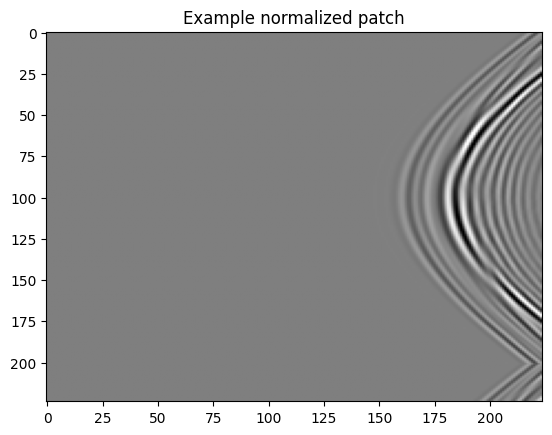

In [4]:
import segyio
import numpy as np
import os
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader

# --- Configuration ---
LOCAL_FILE_NAME = "/kaggle/working/seismic.sgy"
BATCH_SIZE = 16
PATCH_SIZE = 224

# =====================================================
# I. SEG-Y LOADING
# =====================================================

def segy_to_numpy(filename):
    if not os.path.exists(filename):
        print(f"File not found: {filename}")
        return None

    print(f"Loading SEG-Y file: {filename}...")
    with segyio.open(filename, 'r', ignore_geometry=True) as f:
        traces = np.stack([f.trace[i] for i in range(f.tracecount)])

    return np.ascontiguousarray(traces)

# =====================================================
# II. GLOBAL NORMALIZATION + PATCHING
# =====================================================

def create_image_patches(seismic_data_np, patch_size=PATCH_SIZE, clip_sigma=5.0):

    mu = float(seismic_data_np.mean())
    sigma = float(seismic_data_np.std() + 1e-9)

    norm = (seismic_data_np - mu) / sigma
    norm = np.clip(norm, -clip_sigma, clip_sigma)

    traces, samples = norm.shape
    patches = []

    for i in range(0, traces - patch_size + 1, patch_size):
        for j in range(0, samples - patch_size + 1, patch_size):

            patch = norm[i:i+patch_size, j:j+patch_size]

            if patch.shape == (patch_size, patch_size):
                patches.append(patch.astype(np.float32))

    print(f"Extracted {len(patches)} patches of shape {patch_size}x{patch_size}")
    print("Example patch:", patches[0].dtype, patches[0].shape)

    return patches, mu, sigma

# =====================================================
# III. DATASET
# =====================================================

class SeismicDataset(Dataset):
    def __init__(self, patches):
        self.patches = patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):

        patch = torch.from_numpy(self.patches[idx]).unsqueeze(0)  # (1,224,224)

        return patch, patch

# =====================================================
# IV. DATALOADER
# =====================================================

def get_unet_dataloader(patches):
    dataset = SeismicDataset(patches)
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# =====================================================
# V. EXECUTION
# =====================================================

seismic_data_np = segy_to_numpy(LOCAL_FILE_NAME)

if seismic_data_np is not None:

    image_patches, GLOBAL_MEAN, GLOBAL_STD = create_image_patches(seismic_data_np)

    unet_dataloader = get_unet_dataloader(image_patches)

    first_batch = next(iter(unet_dataloader))
    X_batch, Y_batch = first_batch

    print("Batch shape:", X_batch.shape)

    plt.imshow(image_patches[0], cmap="gray", aspect="auto")
    plt.title("Example normalized patch")
    plt.show()



--- Visualizing Rotated Patch ---
Rotating 90 degrees clockwise to match standard seismic orientation (Traces on top, Time/Depth going down).
Original shape: (224, 224)
Rotated shape:  (224, 224)


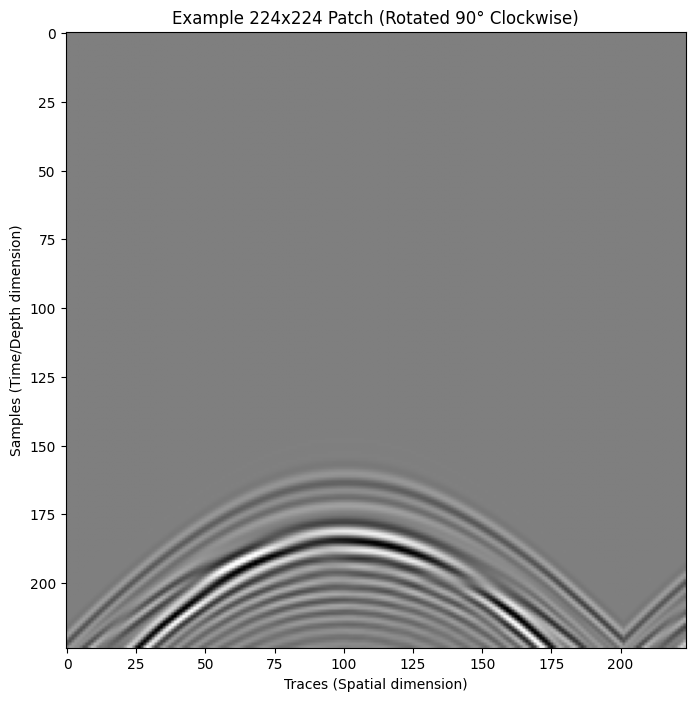

In [5]:
# --- VI. CORRECTED VISUALIZATION (Follow-up Cell) ---

# Ensure we have patches to visualize
if 'image_patches' in locals() and len(image_patches) > 0:
    print("\n--- Visualizing Rotated Patch ---")
    print("Rotating 90 degrees clockwise to match standard seismic orientation (Traces on top, Time/Depth going down).")

    # 1. Get the same first patch again
    original_patch = image_patches[0]

    # 2. Apply Transpose (.T) to swap axes.
    # Original shape was (Traces, Samples). New shape is (Samples, Traces).
    rotated_patch = original_patch.T

    print(f"Original shape: {original_patch.shape}")
    print(f"Rotated shape:  {rotated_patch.shape}")

    # 3. Plot the rotated patch
    plt.figure(figsize=(8, 8)) # Optional: make it a bit bigger
    plt.imshow(rotated_patch, aspect='auto', cmap='gray')
    plt.title("Example 224x224 Patch (Rotated 90° Clockwise)")

    # IMPORTANT: Update labels to reflect the rotation
    plt.xlabel("Traces (Spatial dimension)")
    plt.ylabel("Samples (Time/Depth dimension)")

    # Often in seismic, we want depth/time to increase downwards,
    # though imshow usually does this by default for matrices.
    # If it looks upside down, uncomment the next line:
    # plt.gca().invert_yaxis()

    plt.show()
else:
    print("No patches found in memory. Please run the previous code block successfully first.")

In [6]:
import segyio
import numpy as np
import os

# --- Configuration ---
LOCAL_FILE_NAME = "/kaggle/working/seismic.sgy"
PATCH_SIZE = 224

# --- I. DATA LOADING ---

def segy_to_numpy(filename):
    print(f"Loading {filename}...")
    try:
        with segyio.open(filename, 'r', ignore_geometry=True) as f:
            return np.stack([f.trace[i] for i in range(f.tracecount)])
    except Exception as e:
        print(f"Error loading SEG-Y: {e}")
        return None

# --- II. PATCHING (RAW, NO NORMALIZATION) ---

def create_raw_patches(seismic_data_np, patch_size=PATCH_SIZE):
    print(f"\n--- Extracting Raw Patches ({patch_size}x{patch_size}) ---")
    traces, samples = seismic_data_np.shape
    patches = []

    for i in range(0, traces - patch_size + 1, patch_size):
        for j in range(0, samples - patch_size + 1, patch_size):
            patch = seismic_data_np[i:i+patch_size, j:j+patch_size]
            patches.append(patch)

    print(f"Extracted {len(patches)} patches.")
    return patches

# --- Execution ---
raw_data = segy_to_numpy(LOCAL_FILE_NAME)

if raw_data is not None:
    patches = create_raw_patches(raw_data)
    print(f"Ready to proceed with {len(patches)} patches.")


Loading /kaggle/working/seismic.sgy...

--- Extracting Raw Patches (224x224) ---
Extracted 3246 patches.
Ready to proceed with 3246 patches.


Original Data Shape: (363609, 625)
Transposed Data Shape: (625, 363609) (Time x Traces)
Created 3246 patches from oriented data.
Actual masked fraction: 0.5


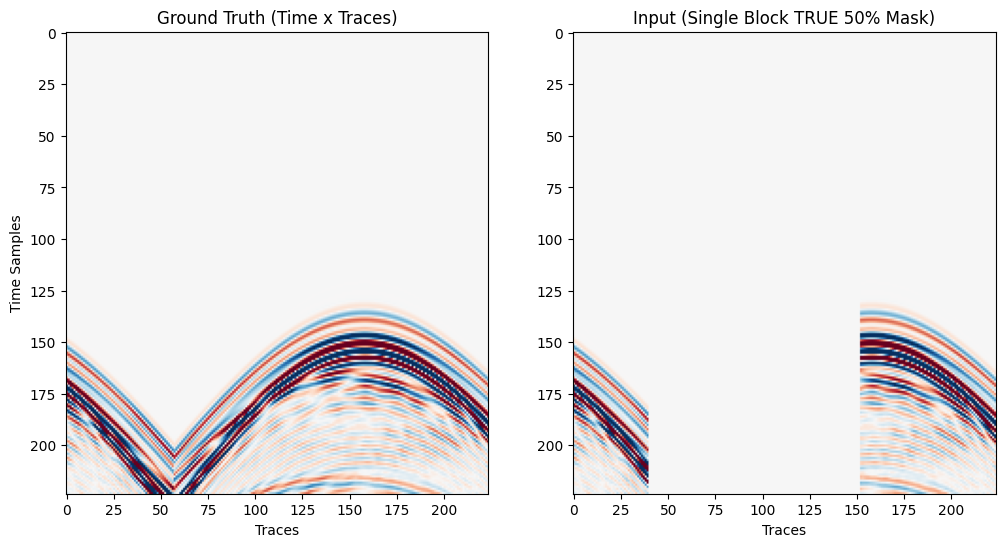

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset

# -------------------------
# 1) FIX ORIENTATION
# -------------------------
def fix_seismic_orientation(data):
    """
    Ensures data is (Time, Traces).
    If input is (Traces, Samples), transpose -> (Samples, Traces).
    """
    print(f"Original Data Shape: {data.shape}")
    data_t = data.T
    print(f"Transposed Data Shape: {data_t.shape} (Time x Traces)")
    return data_t

# -------------------------
# 2) PATCHING
# -------------------------
def create_oriented_patches(data, patch_size=224):
    h, w = data.shape  # h=Time, w=Traces
    patches = []
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patches.append(data[i:i+patch_size, j:j+patch_size])
    print(f"Created {len(patches)} patches from oriented data.")
    return patches

# -------------------------
# 3) DATASET (TRUE 50% SINGLE BLOCK MASK)
# -------------------------
class SeismicSingleBlock50MaskDataset(Dataset):
    """
    Masks exactly 50% of the WIDTH (trace axis) as ONE contiguous vertical block.
    Returns:
      masked_img: (1, H, W)
      gt_img:     (1, H, W)
      mask:       (1, H, W)   0 = masked, 1 = visible
    """
    def __init__(self, patches, mask_ratio=0.5):
        self.patches = patches
        self.mask_ratio = float(mask_ratio)
        assert 0.0 < self.mask_ratio < 1.0, "mask_ratio must be between 0 and 1"

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch = self.patches[idx].astype(np.float32)

        # ---- Normalize (same as your logic) ----
        std = np.std(patch)
        if std > 0:
            patch = patch / (3 * std)
        patch = np.clip(patch, -1, 1)

        # ---- To tensor (1, H, W) ----
        gt = torch.from_numpy(patch).float().unsqueeze(0)
        c, h, w = gt.shape

        # ---- Build mask (single contiguous block) ----
        mask = torch.ones((c, h, w), dtype=torch.float32)

        gap_width = int(round(w * self.mask_ratio))  # for w=224, ratio=0.5 -> 112 exactly
        # IMPORTANT: +1 makes the randint inclusive on last valid start
        start = torch.randint(0, w - gap_width + 1, (1,)).item()

        mask[:, :, start:start + gap_width] = 0.0

        masked = gt * mask

        # ---- Verify actual masked fraction (should be exactly 0.5 for w=224) ----
        actual_masked_fraction = (mask == 0).float().mean().item()

        return masked, gt, mask, actual_masked_fraction

# -------------------------
# 4) EXECUTION & VISUALIZATION
# -------------------------
if 'raw_data' in locals():
    oriented_data = fix_seismic_orientation(raw_data)

    patches = create_oriented_patches(oriented_data, patch_size=224)

    ds = SeismicSingleBlock50MaskDataset(patches, mask_ratio=0.5)

    masked, gt, mask, frac = ds[15]
    print("Actual masked fraction:", frac)

    vis_masked = masked.squeeze().numpy()
    vis_gt = gt.squeeze().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(vis_gt, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
    ax[0].set_title("Ground Truth (Time x Traces)")
    ax[0].set_xlabel("Traces")
    ax[0].set_ylabel("Time Samples")

    ax[1].imshow(vis_masked, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
    ax[1].set_title("Input (Single Block TRUE 50% Mask)")
    ax[1].set_xlabel("Traces")

    plt.show()

else:
    print("Please ensure 'raw_data' is loaded first.")


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Dataset
import math
import numpy as np
from tqdm import tqdm
import os

# ============================================================
# 0. CONFIG
# ============================================================
TIMESTEPS = 1000
IMAGE_SIZE = 224

DATA_CHANNELS = 1              # seismic amplitude is single-channel
IN_CHANNELS = 3                # [x_noisy, masked_img, mask]
OUT_CHANNELS = 1               # predict noise for seismic

BATCH_SIZE = 8
LEARNING_RATE = 1e-4
EPOCHS = 100

MASK_RATIO = 0.5               # EXACT 50% width block
CHECKPOINT_DIR = "/kaggle/working/seismic_checkpoints"

# IMPORTANT: Use a NEW checkpoint name for the inpainting model so you don't collide with old 1-channel runs
INPUT_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "ddpm_inpaint_latest.pt")

SAVE_EVERY_N_EPOCHS = 5
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Loss weights (amplitude fix)
LAMBDA_X0 = 1.0   # start with 1.0; you can try 0.5 or 2.0

# ============================================================
# 1. CHECKPOINT HELPERS (safe load)
# ============================================================
def save_checkpoint(model, optimizer, epoch, loss, filename):
    ckpt = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss,
        "config": {
            "TIMESTEPS": TIMESTEPS,
            "MASK_RATIO": MASK_RATIO,
            "IN_CHANNELS": IN_CHANNELS,
            "OUT_CHANNELS": OUT_CHANNELS
        }
    }
    torch.save(ckpt, filename)
    print(f"  --> Checkpoint saved: {filename}")

def load_checkpoint(model, optimizer, filename, device):
    if not os.path.exists(filename):
        print("❌ No checkpoint found. Starting fresh.")
        return 1

    print(f"✅ Loading checkpoint: {filename}")
    ckpt = torch.load(filename, map_location=device)

    if not (isinstance(ckpt, dict) and "model_state_dict" in ckpt):
        print("⚠️ Not a full checkpoint. Starting fresh.")
        return 1

    # SAFETY: skip load if architecture mismatch
    try:
        model.load_state_dict(ckpt["model_state_dict"], strict=True)
    except RuntimeError as e:
        print("⚠️ Checkpoint load failed (likely shape mismatch). Starting fresh.")
        print("Reason:", str(e).split("\n")[0])
        return 1

    if optimizer is not None and "optimizer_state_dict" in ckpt:
        try:
            optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        except Exception as e:
            print("⚠️ Optimizer state couldn't be loaded. Continuing with fresh optimizer state.")
            print("Reason:", e)

    start_epoch = int(ckpt.get("epoch", 0)) + 1
    print(f"🚀 Resuming from epoch {start_epoch}")
    return start_epoch

# ============================================================
# 2. EXACT 50% SINGLE-BLOCK MASKING
# ============================================================
def apply_vertical_mask_single_block(patch_tensor, mask_ratio=0.5):
    c, h, w = patch_tensor.shape
    mask = torch.ones((c, h, w), dtype=patch_tensor.dtype)
    gap_width = int(round(w * mask_ratio))
    start = torch.randint(0, w - gap_width + 1, (1,)).item()
    mask[:, :, start:start + gap_width] = 0.0
    return patch_tensor * mask, mask

# ============================================================
# 3. DATASET (keeps current behavior, but supports global normalization)
# ============================================================
class SeismicInpaintDataset(Dataset):
    """
    Keeps your current behavior by default:
      - per-patch std normalization + clip [-1,1]
    If you pass global_mean/global_std, it uses global standardization instead
    (recommended for amplitude fidelity).
    """
    def __init__(self, patches, mask_ratio=0.5, global_mean=None, global_std=None, clip_sigma=5.0):
        self.patches = patches
        self.mask_ratio = float(mask_ratio)
        self.global_mean = global_mean
        self.global_std = global_std
        self.clip_sigma = float(clip_sigma)

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        patch = self.patches[idx].astype(np.float32)

        # ---- Normalization ----
        if (self.global_mean is not None) and (self.global_std is not None):
            # Global standardization (best for amplitude)
            patch = (patch - self.global_mean) / (self.global_std + 1e-9)
            patch = np.clip(patch, -self.clip_sigma, self.clip_sigma)
        else:
            # Your original behavior (kept for compatibility)
            std = np.std(patch)
            if std > 0:
                patch = patch / (3 * std)
            patch = np.clip(patch, -1.0, 1.0)

        clean = torch.from_numpy(patch).float().unsqueeze(0)  # (1,H,W)
        masked, mask = apply_vertical_mask_single_block(clean, self.mask_ratio)

        return masked, clean, mask

# ============================================================
# 4. MODEL (unchanged)
# ============================================================
def get_time_embedding(timesteps, embedding_dim=128):
    half_dim = embedding_dim // 2
    emb = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
    timesteps = timesteps.float().unsqueeze(1)
    emb = timesteps * emb.unsqueeze(0)
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if embedding_dim % 2 == 1:
        emb = F.pad(emb, [0, 1])
    return emb

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_embedding_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.gn1 = nn.GroupNorm(8, out_channels)
        self.bn1 = nn.BatchNorm2d(out_channels)          # FIX 1: added — was missing
        self.time_proj = nn.Linear(time_embedding_dim, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.gn2 = nn.GroupNorm(8, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)          # FIX 2: added — was missing
        self.residual_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.gn1(h)
        h = self.bn1(F.silu(h))
        time_term = self.time_proj(F.silu(t_emb))
        h = h + time_term.view(-1, time_term.size(-1), 1, 1)
        h = self.conv2(h)
        h = self.gn2(h)
        h = self.bn2(F.silu(h))                          # FIX 3: was self.bn1 — changed to self.bn2
        return h + self.residual_conv(x)

class Unet(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, out_channels=OUT_CHANNELS, dim=64, dim_mults=(1,2,4,8)):
        super().__init__()
        self.time_embedding_dim = dim * 4
        self.init_conv = nn.Conv2d(in_channels, dim, 7, padding=3)

        dims = [dim, *[dim * m for m in dim_mults]]
        in_out = list(zip(dims[:-1], dims[1:]))

        self.downs = nn.ModuleList([])
        for i, (dim_in, dim_out) in enumerate(in_out):
            self.downs.append(nn.ModuleList([
                ResidualBlock(dim_in, dim_out, self.time_embedding_dim),
                ResidualBlock(dim_out, dim_out, self.time_embedding_dim),
                nn.MaxPool2d(2) if i != len(in_out) - 1 else nn.Identity()
            ]))

        mid_dim = dims[-1]
        self.mid_block1 = ResidualBlock(mid_dim, mid_dim, self.time_embedding_dim)
        self.mid_block2 = ResidualBlock(mid_dim, mid_dim, self.time_embedding_dim)

        self.ups = nn.ModuleList([])
        for i, (dim_in, dim_out) in enumerate(reversed(in_out)):
            self.ups.append(nn.ModuleList([
                ResidualBlock(dim_out + dim_out, dim_in, self.time_embedding_dim),
                ResidualBlock(dim_in, dim_in, self.time_embedding_dim),
                nn.Upsample(scale_factor=2, mode='nearest') if i != len(in_out) - 1 else nn.Identity()
            ]))

        self.final_conv = nn.Conv2d(dim, out_channels, 1)

    def forward(self, x, timesteps):
        t_emb = get_time_embedding(timesteps, self.time_embedding_dim)
        x = self.init_conv(x)
        h = []
        for res1, res2, down in self.downs:
            x = res1(x, t_emb)
            x = res2(x, t_emb)
            h.append(x)
            x = down(x)
        x = self.mid_block1(x, t_emb)
        x = self.mid_block2(x, t_emb)
        for res1, res2, up in self.ups:
            skip = h.pop()
            x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat((x, skip), dim=1)
            x = res1(x, t_emb)
            x = res2(x, t_emb)
            x = up(x)
        return self.final_conv(x)

# ============================================================
# 5. DIFFUSION SCHEDULE
# ============================================================
class NoiseSchedule(object):
    def __init__(self, timesteps=TIMESTEPS, beta_start=1e-4, beta_end=0.02):
        self.timesteps = timesteps
        self.betas = torch.linspace(beta_start, beta_end, timesteps)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, axis=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def _extract(self, a, t, x_shape):
        b, *_ = t.shape
        out = a.gather(-1, t)
        return out.reshape(b, *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)
        t = t.to(x_start.device)
        sqrt_alpha_bar_t = self._extract(self.sqrt_alphas_cumprod.to(x_start.device), t, x_start.shape)
        sqrt_one_minus_alpha_bar_t = self._extract(self.sqrt_one_minus_alphas_cumprod.to(x_start.device), t, x_start.shape)
        return sqrt_alpha_bar_t * x_start + sqrt_one_minus_alpha_bar_t * noise, noise

# ============================================================
# 6. TRAINING LOOP (adds x0 reconstruction loss + missing-region error metrics)
# ============================================================
@torch.no_grad()
def masked_metrics(pred_x0, gt_x0, missing_mask):
    # missing_mask: 1 on missing region, 0 elsewhere
    mae = (torch.abs(pred_x0 - gt_x0) * missing_mask).sum() / (missing_mask.sum() + 1e-8)
    rmse = torch.sqrt((((pred_x0 - gt_x0) ** 2) * missing_mask).sum() / (missing_mask.sum() + 1e-8))
    return float(mae.item()), float(rmse.item())

def train_seismic_inpainting_ddpm(patches_list, global_mean=None, global_std=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    dataset = SeismicInpaintDataset(
        patches_list,
        mask_ratio=MASK_RATIO,
        global_mean=global_mean,
        global_std=global_std
    )

    train_size = int(0.9 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    model = Unet(in_channels=IN_CHANNELS, out_channels=OUT_CHANNELS).to(device)
    schedule = NoiseSchedule()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    start_epoch = load_checkpoint(model, optimizer, INPUT_CHECKPOINT, device)

    for epoch in range(start_epoch, EPOCHS + 1):
        # ---------------- TRAIN ----------------
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
        for masked, clean, mask in pbar:
            masked = masked.to(device)   # (B,1,H,W)
            clean = clean.to(device)     # (B,1,H,W)
            mask = mask.to(device)       # (B,1,H,W)

            t = torch.randint(0, TIMESTEPS, (clean.shape[0],), device=device).long()

            noise = torch.randn_like(clean)
            x_noisy, noise = schedule.q_sample(clean, t, noise)

            model_in = torch.cat([x_noisy, masked, mask], dim=1)  # (B,3,H,W)
            pred_noise = model(model_in, t)                       # (B,1,H,W)

            missing = (1.0 - mask)

            # (A) original noise loss on missing region (kept)
            loss_noise = F.mse_loss(pred_noise * missing, noise * missing)

            # (B) amplitude-aware x0 reconstruction loss on missing region (added)
            alpha_bar_t = schedule._extract(schedule.alphas_cumprod.to(device), t, clean.shape)
            sqrt_alpha_bar = torch.sqrt(alpha_bar_t)
            sqrt_one_minus = torch.sqrt(1.0 - alpha_bar_t)

            x0_hat = (x_noisy - sqrt_one_minus * pred_noise) / (sqrt_alpha_bar + 1e-8)
            loss_x0 = F.l1_loss(x0_hat * missing, clean * missing)

            # (C) KL Divergence loss
            pred_m     = pred_noise * missing
            target_m   = noise * missing
            mu_pred    = pred_m.mean(dim=[1,2,3])
            var_pred   = pred_m.var(dim=[1,2,3])   + 1e-8
            mu_target  = target_m.mean(dim=[1,2,3])
            var_target = target_m.var(dim=[1,2,3])  + 1e-8
            loss_kl    = 0.5 * (var_pred/var_target + (mu_target - mu_pred)**2 / var_target
                                - 1.0 + torch.log(var_target / var_pred)).mean()

            loss = loss_noise + LAMBDA_X0 * loss_x0 + 0.1 * loss_kl

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=float(loss.item()), ln=float(loss_noise.item()), lx0=float(loss_x0.item()), kl=float(loss_kl.item()))

        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch} | Avg Loss: {avg_loss:.5f}")

        # ---------------- VALIDATE (missing-region error) ----------------
        model.eval()
        v_mae, v_rmse, n_batches = 0.0, 0.0, 0
        with torch.no_grad():
            for masked, clean, mask in val_loader:
                masked = masked.to(device)
                clean = clean.to(device)
                mask = mask.to(device)

                t = torch.randint(0, TIMESTEPS, (clean.shape[0],), device=device).long()
                noise = torch.randn_like(clean)
                x_noisy, noise = schedule.q_sample(clean, t, noise)

                model_in = torch.cat([x_noisy, masked, mask], dim=1)
                pred_noise = model(model_in, t)

                alpha_bar_t = schedule._extract(schedule.alphas_cumprod.to(device), t, clean.shape)
                x0_hat = (x_noisy - torch.sqrt(1.0 - alpha_bar_t) * pred_noise) / (torch.sqrt(alpha_bar_t) + 1e-8)

                missing = (1.0 - mask)
                mae, rmse = masked_metrics(x0_hat, clean, missing)
                v_mae += mae
                v_rmse += rmse
                n_batches += 1

        if n_batches > 0:
            print(f"  Val Missing MAE: {v_mae/n_batches:.5f} | RMSE: {v_rmse/n_batches:.5f}")

        # ---------------- SAVE ----------------
        latest_path = os.path.join(CHECKPOINT_DIR, "ddpm_inpaint_latest.pt")
        save_checkpoint(model, optimizer, epoch, avg_loss, latest_path)

        if epoch % SAVE_EVERY_N_EPOCHS == 0:
            epoch_path = os.path.join(CHECKPOINT_DIR, f"ddpm_inpaint_epoch_{epoch:03d}.pt")
            save_checkpoint(model, optimizer, epoch, avg_loss, epoch_path)

    print("✅ Training complete (conditional interpolation DDPM + amplitude fix).")
    return model, schedule

# ============================================================
# 7. RUN
# ============================================================
if __name__ == "__main__":
    if "patches" in locals() and len(patches) > 0:
        # If you computed GLOBAL_MEAN/GLOBAL_STD earlier, pass them here:
        # trained_model, noise_schedule = train_seismic_inpainting_ddpm(patches, global_mean=GLOBAL_MEAN, global_std=GLOBAL_STD)

        # If not, it will fall back to your original per-patch std+clip behavior:
        trained_model, noise_schedule = train_seismic_inpainting_ddpm(patches)
    else:
        print("❌ 'patches' not found. Run your data loading + patch creation first.")

Device: cuda
❌ No checkpoint found. Starting fresh.


Epoch 1 | Avg Loss: 1.45281


  Val Missing MAE: 1.62023 | RMSE: 3.61109
  --> Checkpoint saved: /kaggle/working/seismic_checkpoints/ddpm_inpaint_latest.pt


Epoch 2 | Avg Loss: 0.55611


  Val Missing MAE: 0.79466 | RMSE: 2.22700
  --> Checkpoint saved: /kaggle/working/seismic_checkpoints/ddpm_inpaint_latest.pt


...

  Val Missing MAE: 0.17204 | RMSE: 0.31981
  --> Checkpoint saved: /kaggle/working/seismic_checkpoints/ddpm_inpaint_latest.pt


Epoch 99 | Avg Loss: 0.10263


  Val Missing MAE: 0.16933 | RMSE: 0.28792
  --> Checkpoint saved: /kaggle/working/seismic_checkpoints/ddpm_inpaint_latest.pt


Epoch 100 | Avg Loss: 0.10704


  Val Missing MAE: 0.15946 | RMSE: 0.28219
  --> Checkpoint saved: /kaggle/working/seismic_checkpoints/ddpm_inpaint_latest.pt
  --> Checkpoint saved: /kaggle/working/seismic_checkpoints/ddpm_inpaint_epoch_100.pt
✅ Training complete (conditional interpolation DDPM + amplitude fix).


Using device: cuda
✅ Model loaded from checkpoint (epoch 100)
Loaded 3246 patches

Testing patch index: 0


Reconstructing: 100%|██████████| 1000/1000 [00:20<00:00, 48.67it/s]


  MAE  (missing region): 0.15656
  RMSE (missing region): 0.36593


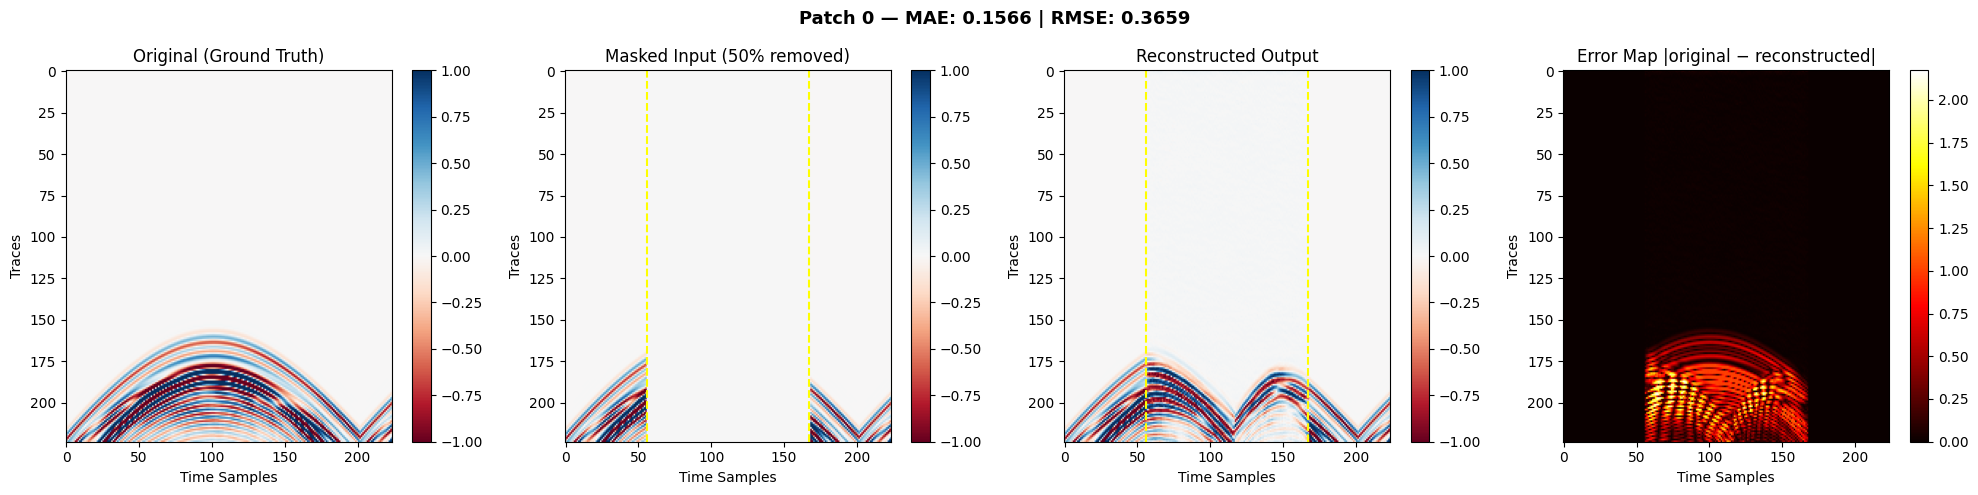

  Saved: /kaggle/working/test_patch_0.png

Testing patch index: 100


Reconstructing: 100%|██████████| 1000/1000 [00:20<00:00, 48.74it/s]


  MAE  (missing region): 0.16153
  RMSE (missing region): 0.33662


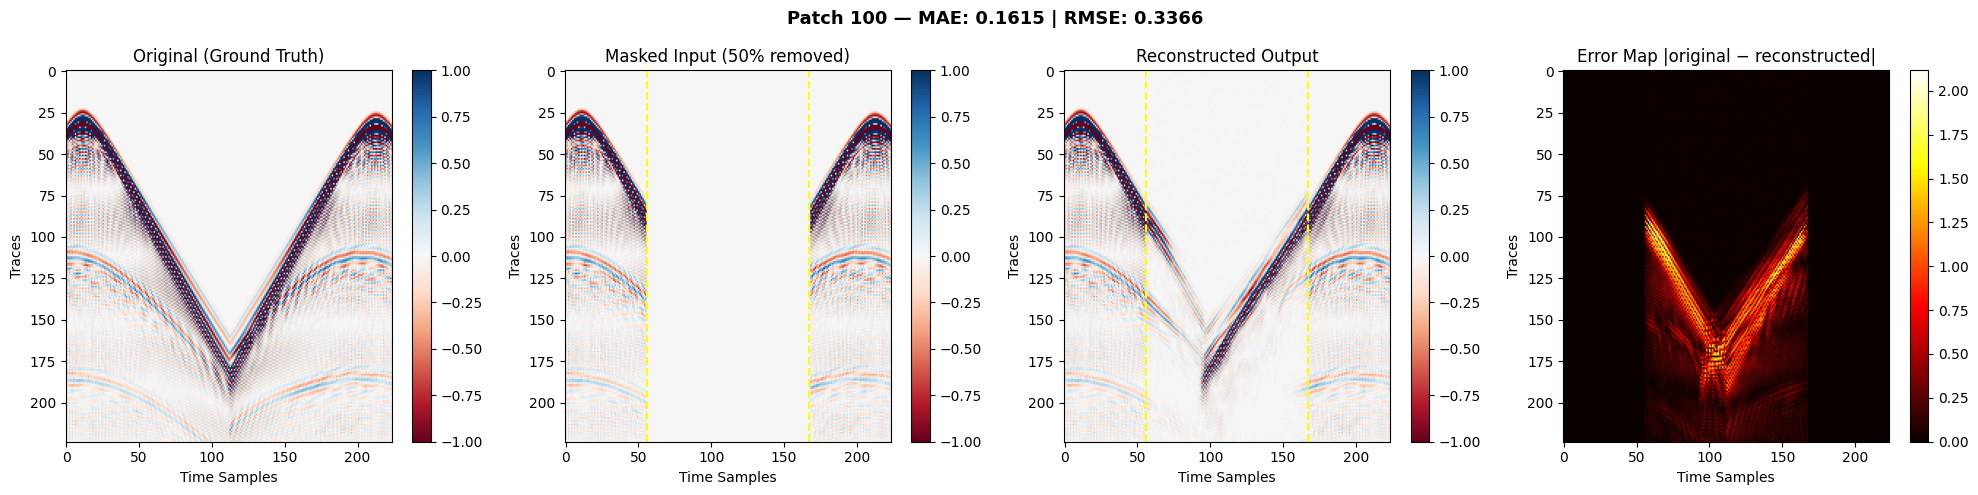

  Saved: /kaggle/working/test_patch_100.png

Testing patch index: 500


Reconstructing: 100%|██████████| 1000/1000 [00:20<00:00, 48.73it/s]


  MAE  (missing region): 0.13846
  RMSE (missing region): 0.31959


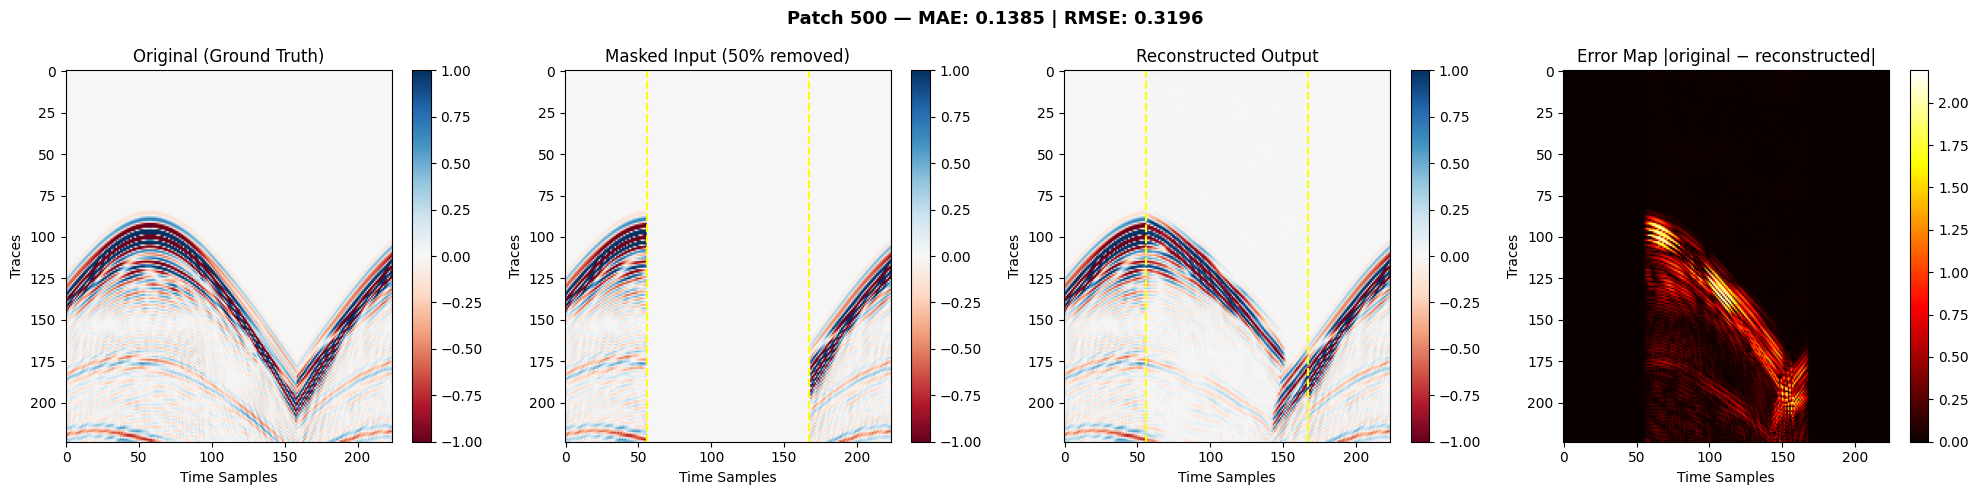

  Saved: /kaggle/working/test_patch_500.png

Testing patch index: 1000


Reconstructing: 100%|██████████| 1000/1000 [00:20<00:00, 48.74it/s]


  MAE  (missing region): 0.16896
  RMSE (missing region): 0.33582


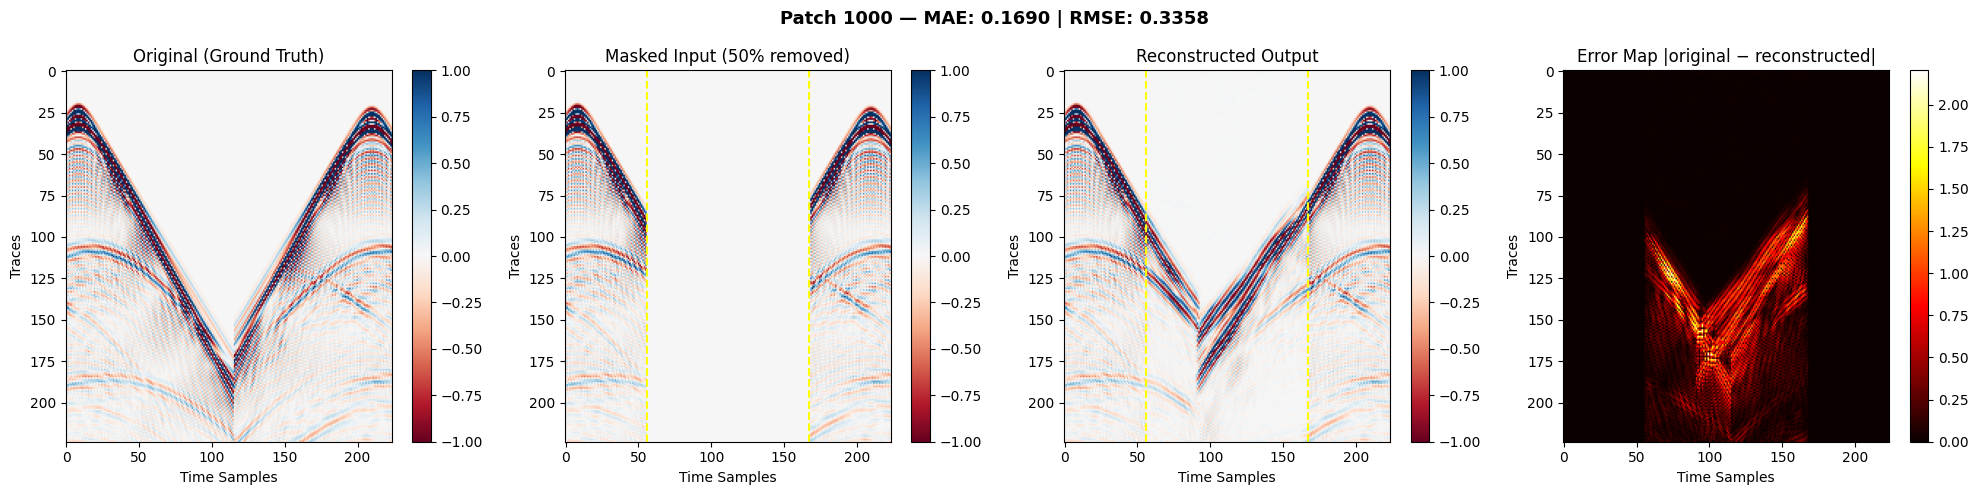

  Saved: /kaggle/working/test_patch_1000.png

Testing patch index: 2000


Reconstructing: 100%|██████████| 1000/1000 [00:20<00:00, 48.74it/s]


  MAE  (missing region): 0.18582
  RMSE (missing region): 0.30446


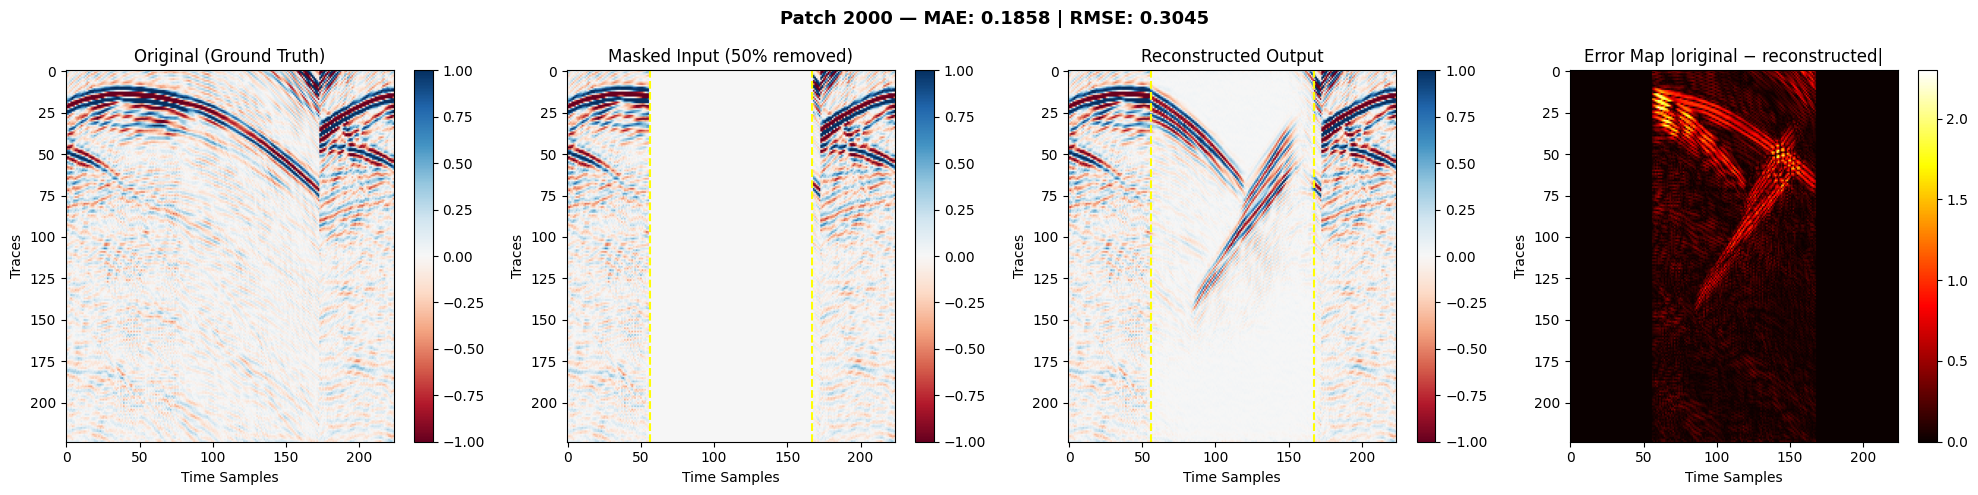

  Saved: /kaggle/working/test_patch_2000.png

AMPLITUDE CHECK — missing region only
Patch       GT mean     GT std    Pred mean   Pred std      MAE
------------------------------------------------------------


Reconstructing: 100%|██████████| 1000/1000 [00:20<00:00, 48.75it/s]


0           -0.0013     0.2899       0.0076     0.2319   0.1540


Reconstructing: 100%|██████████| 1000/1000 [00:20<00:00, 48.74it/s]


100          0.0001     0.2698       0.0026     0.1959   0.1509


...

Reconstructing: 100%|██████████| 1000/1000 [00:20<00:00, 48.75it/s]


1000        -0.0002     0.2578       0.0025     0.2142   0.1569


Reconstructing: 100%|██████████| 1000/1000 [00:20<00:00, 48.75it/s]


2000         0.0006     0.2273       0.0070     0.1926   0.1799
------------------------------------------------------------
Pred mean ≈ GT mean  AND  Pred std ≈ GT std  →  amplitude correct ✅
Pred std << GT std                           →  model predicting too flat ⚠️

Plotting single trace comparison for patch 0...


Reconstructing: 100%|██████████| 1000/1000 [00:20<00:00, 48.75it/s]


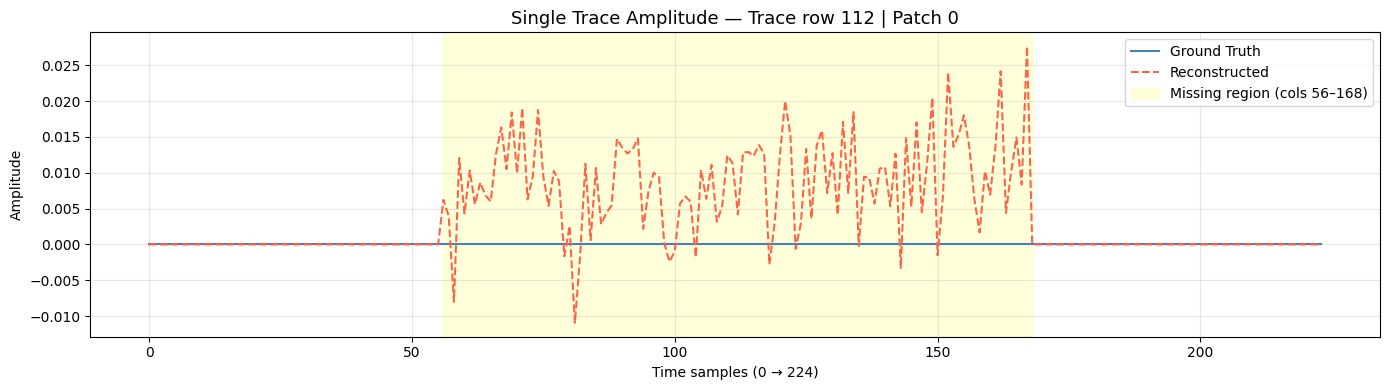

Saved: /kaggle/working/trace_comparison.png

✅ All tests complete.


In [9]:
# ============================================================
# DDPM SEISMIC — INFERENCE & TESTING CODE
# Run this as a new cell in your Kaggle notebook AFTER training
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import os
from tqdm import tqdm

# ============================================================
# STEP 0 — CONFIG
# ============================================================
TIMESTEPS    = 1000
IN_CHANNELS  = 3       # [x_noisy, masked_img, mask]
OUT_CHANNELS = 1
CHECKPOINT   = "/kaggle/working/seismic_checkpoints/ddpm_inpaint_latest.pt"
PATCHES_FILE = "/kaggle/working/seismic_patches.npy"
MASK_RATIO   = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# NOTE ON ORIENTATION
# ============================================================
# Patches are stored as (traces, samples) — shape (224, 224)
# In tensor form: (1, H, W) where H=traces, W=samples(time)
# The mask removes W columns  →  appears as VERTICAL strips in raw imshow
# We do NOT transpose for display — raw orientation already shows vertical masking correctly
# Axis labels: X = time samples (0→224), Y = traces (0→224)
# ============================================================

# ============================================================
# STEP 1 — MODEL DEFINITION (identical to training)
# ============================================================
def get_time_embedding(timesteps, embedding_dim=128):
    half_dim = embedding_dim // 2
    emb = math.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, device=timesteps.device) * -emb)
    timesteps = timesteps.float().unsqueeze(1)
    emb = timesteps * emb.unsqueeze(0)
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    if embedding_dim % 2 == 1:
        emb = F.pad(emb, [0, 1])
    return emb

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_embedding_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.gn1   = nn.GroupNorm(8, out_channels)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.time_proj = nn.Linear(time_embedding_dim, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.gn2   = nn.GroupNorm(8, out_channels)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.residual_conv = nn.Conv2d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = self.gn1(h)
        h = self.bn1(F.silu(h))
        time_term = self.time_proj(F.silu(t_emb))
        h = h + time_term.view(-1, time_term.size(-1), 1, 1)
        h = self.conv2(h)
        h = self.gn2(h)
        h = self.bn2(F.silu(h))
        return h + self.residual_conv(x)

class Unet(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, out_channels=OUT_CHANNELS, dim=64, dim_mults=(1,2,4,8)):
        super().__init__()
        self.time_embedding_dim = dim * 4
        self.init_conv = nn.Conv2d(in_channels, dim, 7, padding=3)
        dims   = [dim, *[dim * m for m in dim_mults]]
        in_out = list(zip(dims[:-1], dims[1:]))
        self.downs = nn.ModuleList([])
        for i, (dim_in, dim_out) in enumerate(in_out):
            self.downs.append(nn.ModuleList([
                ResidualBlock(dim_in,  dim_out, self.time_embedding_dim),
                ResidualBlock(dim_out, dim_out, self.time_embedding_dim),
                nn.MaxPool2d(2) if i != len(in_out)-1 else nn.Identity()
            ]))
        mid_dim = dims[-1]
        self.mid_block1 = ResidualBlock(mid_dim, mid_dim, self.time_embedding_dim)
        self.mid_block2 = ResidualBlock(mid_dim, mid_dim, self.time_embedding_dim)
        self.ups = nn.ModuleList([])
        for i, (dim_in, dim_out) in enumerate(reversed(in_out)):
            self.ups.append(nn.ModuleList([
                ResidualBlock(dim_out + dim_out, dim_in, self.time_embedding_dim),
                ResidualBlock(dim_in, dim_in, self.time_embedding_dim),
                nn.Upsample(scale_factor=2, mode='nearest') if i != len(in_out)-1 else nn.Identity()
            ]))
        self.final_conv = nn.Conv2d(dim, out_channels, 1)

    def forward(self, x, timesteps):
        t_emb = get_time_embedding(timesteps, self.time_embedding_dim)
        x = self.init_conv(x)
        h = []
        for res1, res2, down in self.downs:
            x = res1(x, t_emb); x = res2(x, t_emb); h.append(x); x = down(x)
        x = self.mid_block1(x, t_emb)
        x = self.mid_block2(x, t_emb)
        for res1, res2, up in self.ups:
            skip = h.pop()
            x = F.interpolate(x, size=skip.shape[2:])
            x = torch.cat((x, skip), dim=1)
            x = res1(x, t_emb); x = res2(x, t_emb); x = up(x)
        return self.final_conv(x)

# ============================================================
# STEP 2 — NOISE SCHEDULE
# ============================================================
class NoiseSchedule:
    def __init__(self, timesteps=TIMESTEPS, beta_start=1e-4, beta_end=0.02):
        self.timesteps       = timesteps
        self.betas           = torch.linspace(beta_start, beta_end, timesteps)
        self.alphas          = 1.0 - self.betas
        self.alphas_cumprod  = torch.cumprod(self.alphas, dim=0)

    def _extract(self, a, t, x_shape):
        out = a.gather(-1, t)
        return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))

# ============================================================
# STEP 3 — REVERSE DIFFUSION LOOP
# ============================================================
@torch.no_grad()
def reconstruct(model, masked_img, mask, schedule, timesteps=TIMESTEPS, device=device):
    model.eval()
    betas      = schedule.betas.to(device)
    alphas     = schedule.alphas.to(device)
    alphas_cum = schedule.alphas_cumprod.to(device)

    x = torch.randn_like(masked_img).to(device)
    x = x * (1 - mask) + masked_img * mask          # keep known region from start

    for t_idx in tqdm(reversed(range(timesteps)), total=timesteps, desc="Reconstructing", leave=True):
        t_tensor   = torch.full((1,), t_idx, device=device, dtype=torch.long)
        model_in   = torch.cat([x, masked_img, mask], dim=1)   # (1,3,H,W)
        pred_noise = model(model_in, t_tensor)                  # (1,1,H,W)

        beta_t    = betas[t_idx]
        alpha_t   = alphas[t_idx]
        alpha_cum = alphas_cum[t_idx]

        coef1 = 1.0 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1.0 - alpha_cum)
        mean  = coef1 * (x - coef2 * pred_noise)

        if t_idx > 0:
            x = mean + torch.sqrt(beta_t) * torch.randn_like(x)
        else:
            x = mean

        x = x * (1 - mask) + masked_img * mask      # paste known region back each step

    return x

# ============================================================
# STEP 4 — LOAD MODEL
# ============================================================
model    = Unet(in_channels=IN_CHANNELS, out_channels=OUT_CHANNELS).to(device)
schedule = NoiseSchedule()

ckpt = torch.load(CHECKPOINT, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"✅ Model loaded from checkpoint (epoch {ckpt['epoch']})")

# ============================================================
# STEP 5 — LOAD PATCHES + HELPERS
# ============================================================
patches = np.load(PATCHES_FILE)    # shape: (N, 224, 224) = (N, traces, samples)
print(f"Loaded {len(patches)} patches")

TEST_INDICES = [0, 100, 500, 1000, 2000]

def normalize_patch(patch):
    std = np.std(patch)
    if std > 0:
        patch = patch / (3 * std)
    return np.clip(patch, -1.0, 1.0).astype(np.float32)

def apply_center_mask(clean_tensor, mask_ratio=0.5):
    """
    Removes a contiguous block along W (last dim = samples/time axis).
    In raw imshow this shows as a VERTICAL strip — matching training behaviour.
    """
    c, h, w = clean_tensor.shape
    mask    = torch.ones((c, h, w), dtype=torch.float32)
    gap     = int(round(w * mask_ratio))
    start   = (w - gap) // 2               # center for consistent visual comparison
    mask[:, :, start:start+gap] = 0.0      # remove W columns  ← matches training
    return clean_tensor * mask, mask, start, start+gap

# ============================================================
# STEP 6 — INFERENCE + VISUALIZE (no transpose — vertical gap displays correctly)
# ============================================================
for patch_idx in TEST_INDICES:
    print(f"\n{'='*50}")
    print(f"Testing patch index: {patch_idx}")
    print(f"{'='*50}")

    raw   = patches[patch_idx]
    norm  = normalize_patch(raw.copy())
    clean = torch.from_numpy(norm).unsqueeze(0)      # (1, H, W)

    masked_img, mask, gap_start, gap_end = apply_center_mask(clean.clone())

    masked_gpu = masked_img.unsqueeze(0).to(device)  # (1,1,H,W)
    mask_gpu   = mask.unsqueeze(0).to(device)
    clean_gpu  = clean.unsqueeze(0).to(device)

    reconstructed = reconstruct(model, masked_gpu, mask_gpu, schedule, device=device)

    # numpy arrays — shape (traces, samples) = (H, W)
    clean_np  = clean_gpu[0, 0].cpu().numpy()
    masked_np = masked_gpu[0, 0].cpu().numpy()
    recon_np  = reconstructed[0, 0].cpu().numpy()

    # Metrics on missing region only — gap is in columns (W axis)
    missing_gt   = clean_np[:, gap_start:gap_end]
    missing_pred = recon_np[:, gap_start:gap_end]
    mae  = float(np.abs(missing_gt - missing_pred).mean())
    rmse = float(np.sqrt(((missing_gt - missing_pred)**2).mean()))
    print(f"  MAE  (missing region): {mae:.5f}")
    print(f"  RMSE (missing region): {rmse:.5f}")

    vmin = clean_np.min()
    vmax = clean_np.max()

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f"Patch {patch_idx} — MAE: {mae:.4f} | RMSE: {rmse:.4f}", fontsize=13, fontweight='bold')

    # No .T — raw shape (traces, samples): Y=traces, X=samples
    # Mask was on X (W/samples), so gap appears as vertical strip ✅
    axes[0].imshow(clean_np,  cmap='RdBu', aspect='auto', vmin=vmin, vmax=vmax)
    axes[0].set_title("Original (Ground Truth)")
    axes[0].set_xlabel("Time Samples")
    axes[0].set_ylabel("Traces")
    plt.colorbar(axes[0].images[0], ax=axes[0])

    axes[1].imshow(masked_np, cmap='RdBu', aspect='auto', vmin=vmin, vmax=vmax)
    axes[1].axvline(x=gap_start,   color='yellow', linewidth=1.5, linestyle='--')   # vertical lines ✅
    axes[1].axvline(x=gap_end - 1, color='yellow', linewidth=1.5, linestyle='--')
    axes[1].set_title("Masked Input (50% removed)")
    axes[1].set_xlabel("Time Samples")
    axes[1].set_ylabel("Traces")
    plt.colorbar(axes[1].images[0], ax=axes[1])

    axes[2].imshow(recon_np,  cmap='RdBu', aspect='auto', vmin=vmin, vmax=vmax)
    axes[2].axvline(x=gap_start,   color='yellow', linewidth=1.5, linestyle='--')
    axes[2].axvline(x=gap_end - 1, color='yellow', linewidth=1.5, linestyle='--')
    axes[2].set_title("Reconstructed Output")
    axes[2].set_xlabel("Time Samples")
    axes[2].set_ylabel("Traces")
    plt.colorbar(axes[2].images[0], ax=axes[2])

    diff = np.abs(clean_np - recon_np)
    im   = axes[3].imshow(diff, cmap='hot', aspect='auto')
    axes[3].set_title("Error Map |original − reconstructed|")
    axes[3].set_xlabel("Time Samples")
    axes[3].set_ylabel("Traces")
    plt.colorbar(im, ax=axes[3])

    plt.tight_layout()
    save_path = f"/kaggle/working/test_patch_{patch_idx}.png"
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {save_path}")

# ============================================================
# STEP 7 — AMPLITUDE CHECK TABLE
# ============================================================
print("\n" + "="*60)
print("AMPLITUDE CHECK — missing region only")
print("="*60)
print(f"{'Patch':<8} {'GT mean':>10} {'GT std':>10} {'Pred mean':>12} {'Pred std':>10} {'MAE':>8}")
print("-"*60)

for patch_idx in TEST_INDICES:
    raw   = patches[patch_idx]
    norm  = normalize_patch(raw.copy())
    clean = torch.from_numpy(norm).unsqueeze(0)
    masked_img, mask, gap_start, gap_end = apply_center_mask(clean.clone())
    masked_gpu = masked_img.unsqueeze(0).to(device)
    mask_gpu   = mask.unsqueeze(0).to(device)
    clean_gpu  = clean.unsqueeze(0).to(device)

    reconstructed = reconstruct(model, masked_gpu, mask_gpu, schedule, device=device)

    gt_region   = clean_gpu[0, 0].cpu().numpy()[:, gap_start:gap_end]
    pred_region = reconstructed[0, 0].cpu().numpy()[:, gap_start:gap_end]

    print(f"{patch_idx:<8} {gt_region.mean():>10.4f} {gt_region.std():>10.4f} "
          f"{pred_region.mean():>12.4f} {pred_region.std():>10.4f} "
          f"{np.abs(gt_region - pred_region).mean():>8.4f}")

print("-"*60)
print("Pred mean ≈ GT mean  AND  Pred std ≈ GT std  →  amplitude correct ✅")
print("Pred std << GT std                           →  model predicting too flat ⚠️")

# ============================================================
# STEP 8 — SINGLE TRACE AMPLITUDE COMPARISON
# Picks one row (a single trace) from inside the gap and
# plots amplitude across time samples
# ============================================================
print("\nPlotting single trace comparison for patch 0...")

raw   = patches[TEST_INDICES[0]]
norm  = normalize_patch(raw.copy())
clean = torch.from_numpy(norm).unsqueeze(0)
masked_img, mask, gap_start, gap_end = apply_center_mask(clean.clone())
masked_gpu = masked_img.unsqueeze(0).to(device)
mask_gpu   = mask.unsqueeze(0).to(device)
reconstructed = reconstruct(model, masked_gpu, mask_gpu, schedule, device=device)

clean_np = clean[0].numpy()                          # (traces, samples)
recon_np = reconstructed[0, 0].cpu().numpy()         # (traces, samples)

# Pick a trace row from the middle of the patch
trace_row = clean_np.shape[0] // 2                   # row 112 out of 224

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(clean_np[trace_row, :], label="Ground Truth",  color="steelblue", linewidth=1.5)
ax.plot(recon_np[trace_row, :], label="Reconstructed", color="tomato",    linewidth=1.5, linestyle='--')
ax.axvspan(gap_start, gap_end, alpha=0.15, color='yellow', label=f"Missing region (cols {gap_start}–{gap_end})")
ax.set_title(f"Single Trace Amplitude — Trace row {trace_row} | Patch {TEST_INDICES[0]}", fontsize=13)
ax.set_xlabel("Time samples (0 → 224)")
ax.set_ylabel("Amplitude")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/trace_comparison.png", dpi=120)
plt.show()
print("Saved: /kaggle/working/trace_comparison.png")
print("\n✅ All tests complete.")

In [3]:
import os
import shutil
from kaggle_secrets import UserSecretsClient

# 1. Access your secured token
user_secrets = UserSecretsClient()
token = user_secrets.get_secret("github_token")

# 2. Project Details
USERNAME = "Harshitha-katturajan" 
REPO_NAME = "Seismic-Data-Interpolation-Using-DDPM-architecture"
EMAIL = "katturajanharshitha@gmail.com" 

# 3. Fix the File Path and Rename
# We search for the notebook file dynamically to avoid the "No such file" error
%cd /kaggle/working
source_path = "/kaggle/working/__notebook_source__.ipynb"

if os.path.exists(source_path):
    shutil.copy(source_path, "Seismic_DDPM_Interpolation.ipynb")
    print("✅ Notebook file found and renamed.")
else:
    # If it's not in the main folder, we look in the virtual documents folder
    alt_path = "/kaggle/working/.virtual_documents/__notebook_source__.ipynb"
    if os.path.exists(alt_path):
        shutil.copy(alt_path, "Seismic_DDPM_Interpolation.ipynb")
        print("✅ Notebook file found in virtual documents and renamed.")
    else:
        print("❌ Notebook file still not found. Try 'Save Version' (top right) first.")

# 4. Re-initialize Git to fix the "not a git repository" error
!git init
!git config --global user.email "{EMAIL}"
!git config --global user.name "{USERNAME}"

# 5. Connect to GitHub
!git remote remove origin 2>/dev/null 
remote_url = f"https://{token}@github.com/{USERNAME}/{REPO_NAME}.git"
!git remote add origin {remote_url}

# 6. Add, Commit, and Push
!git add .
!git commit -m "Fixed file paths and pushed latest Seismic DDPM code"
!git branch -M main
!git push -u origin main --force

/kaggle/working
❌ Notebook file still not found. Try 'Save Version' (top right) first.
Reinitialized existing Git repository in /kaggle/working/.git/
On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/Harshitha-katturajan/Seismic-Data-Interpolation-Using-DDPM-architecture.git'


In [4]:
import os
from kaggle_secrets import UserSecretsClient

# 1. Access your secured token
user_secrets = UserSecretsClient()
token = user_secrets.get_secret("github_token")

# 2. Project Details
USERNAME = "Harshitha-katturajan" 
REPO_NAME = "Seismic-Data-Interpolation-Using-DDPM-architecture"
EMAIL = "katturajanharshitha@gmail.com" 

# 3. Setup the .gitignore
# This ensures large SEG-Y files or temporary numpy data don't bloat your repo
gitignore_content = """
__pycache__/
*.csv
*.npy
*.npz
*.segy
.virtual_documents/
"""
with open("/kaggle/working/.gitignore", "w") as f:
    f.write(gitignore_content)

# 4. Git Commands
%cd /kaggle/working
!git init
!git config --global user.email "{EMAIL}"
!git config --global user.name "{USERNAME}"
!git add .
!git commit -m "Initial commit: Seismic Data Interpolation project with final 100 epoch results"

# 5. Push to GitHub
# We remove the origin first to avoid 'remote origin already exists' errors
!git remote remove origin 2>/dev/null 
remote_url = f"https://{token}@github.com/{USERNAME}/{REPO_NAME}.git"
!git remote add origin {remote_url}
!git branch -M main
!git push -u origin main --force

/kaggle/working
Reinitialized existing Git repository in /kaggle/working/.git/
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Branch 'main' set up to track remote branch 'main' from 'origin'.
Everything up-to-date
